<a href="https://colab.research.google.com/github/bitmorphic/nocap-deepfake/blob/main/notebooks/Week3_GradCAM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NoCap — Deepfake Video Detector
## Week 3 — Grad-CAM + Inference Pipeline

Team:Quad Logic - NIT Delhi

Build Grad-CAM explainability and full video inference pipeline using our trained EfficientNet-B4 model.
- Grad-CAM heatmaps showing suspicious regions on real and fake faces
- Full video inference pipeline: Video → Frames → MTCNN → EfficientNet-B4 → Verdict
- Threshold tuning to find optimal decision boundary



In [1]:
!pip install -q facenet-pytorch

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE   = '/content/drive/MyDrive/NoCap-Deepfake'

from google.colab import drive
drive.mount('/content/drive')

# Build model
def build_model():
    model = models.efficientnet_b4(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 1))
    return model

# Load trained weights
model = build_model().to(DEVICE)
model.load_state_dict(torch.load(
    f'{BASE}/models/checkpoints/efficientnet_b4_dfdc.pth',
    map_location=DEVICE))
model.eval()

print(f'Model loaded!')
print(f'Device: {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

ImportError: cannot import name 'is_directory' from 'PIL._util' (/usr/local/lib/python3.12/dist-packages/PIL/_util.py)

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from google.colab import drive
drive.mount('/content/drive')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE   = '/content/drive/MyDrive/NoCap-Deepfake'

def build_model():
    model = models.efficientnet_b4(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4), nn.Linear(in_features, 1))
    return model

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(
    f'{BASE}/models/checkpoints/efficientnet_b4_dfdc.pth',
    map_location=DEVICE))
model.eval()
print(f'Model loaded! Device: {DEVICE}')

Mounted at /content/drive
Model loaded! Device: cuda


In [2]:
class GradCAM:
    def __init__(self, model):
        self.model   = model
        self.grads   = None
        self.acts    = None
        # Hook into last conv layer of EfficientNet-B4
        target_layer = model.features[-1]
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'acts', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def generate(self, img_tensor):
        self.model.eval()
        out = self.model(img_tensor)
        self.model.zero_grad()
        out[0, 0].backward()
        # Weighted combination of gradients and activations
        w   = self.grads[0].mean(dim=(1, 2))
        cam = F.relu((w[:, None, None] * self.acts[0]).sum(0))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

gradcam = GradCAM(model)
print('Grad-CAM ready')

Grad-CAM ready


Dataset URL: https://www.kaggle.com/datasets/itamargr/dfdc-faces-of-the-train-sample
License(s): ODbL-1.0
Dataset ready


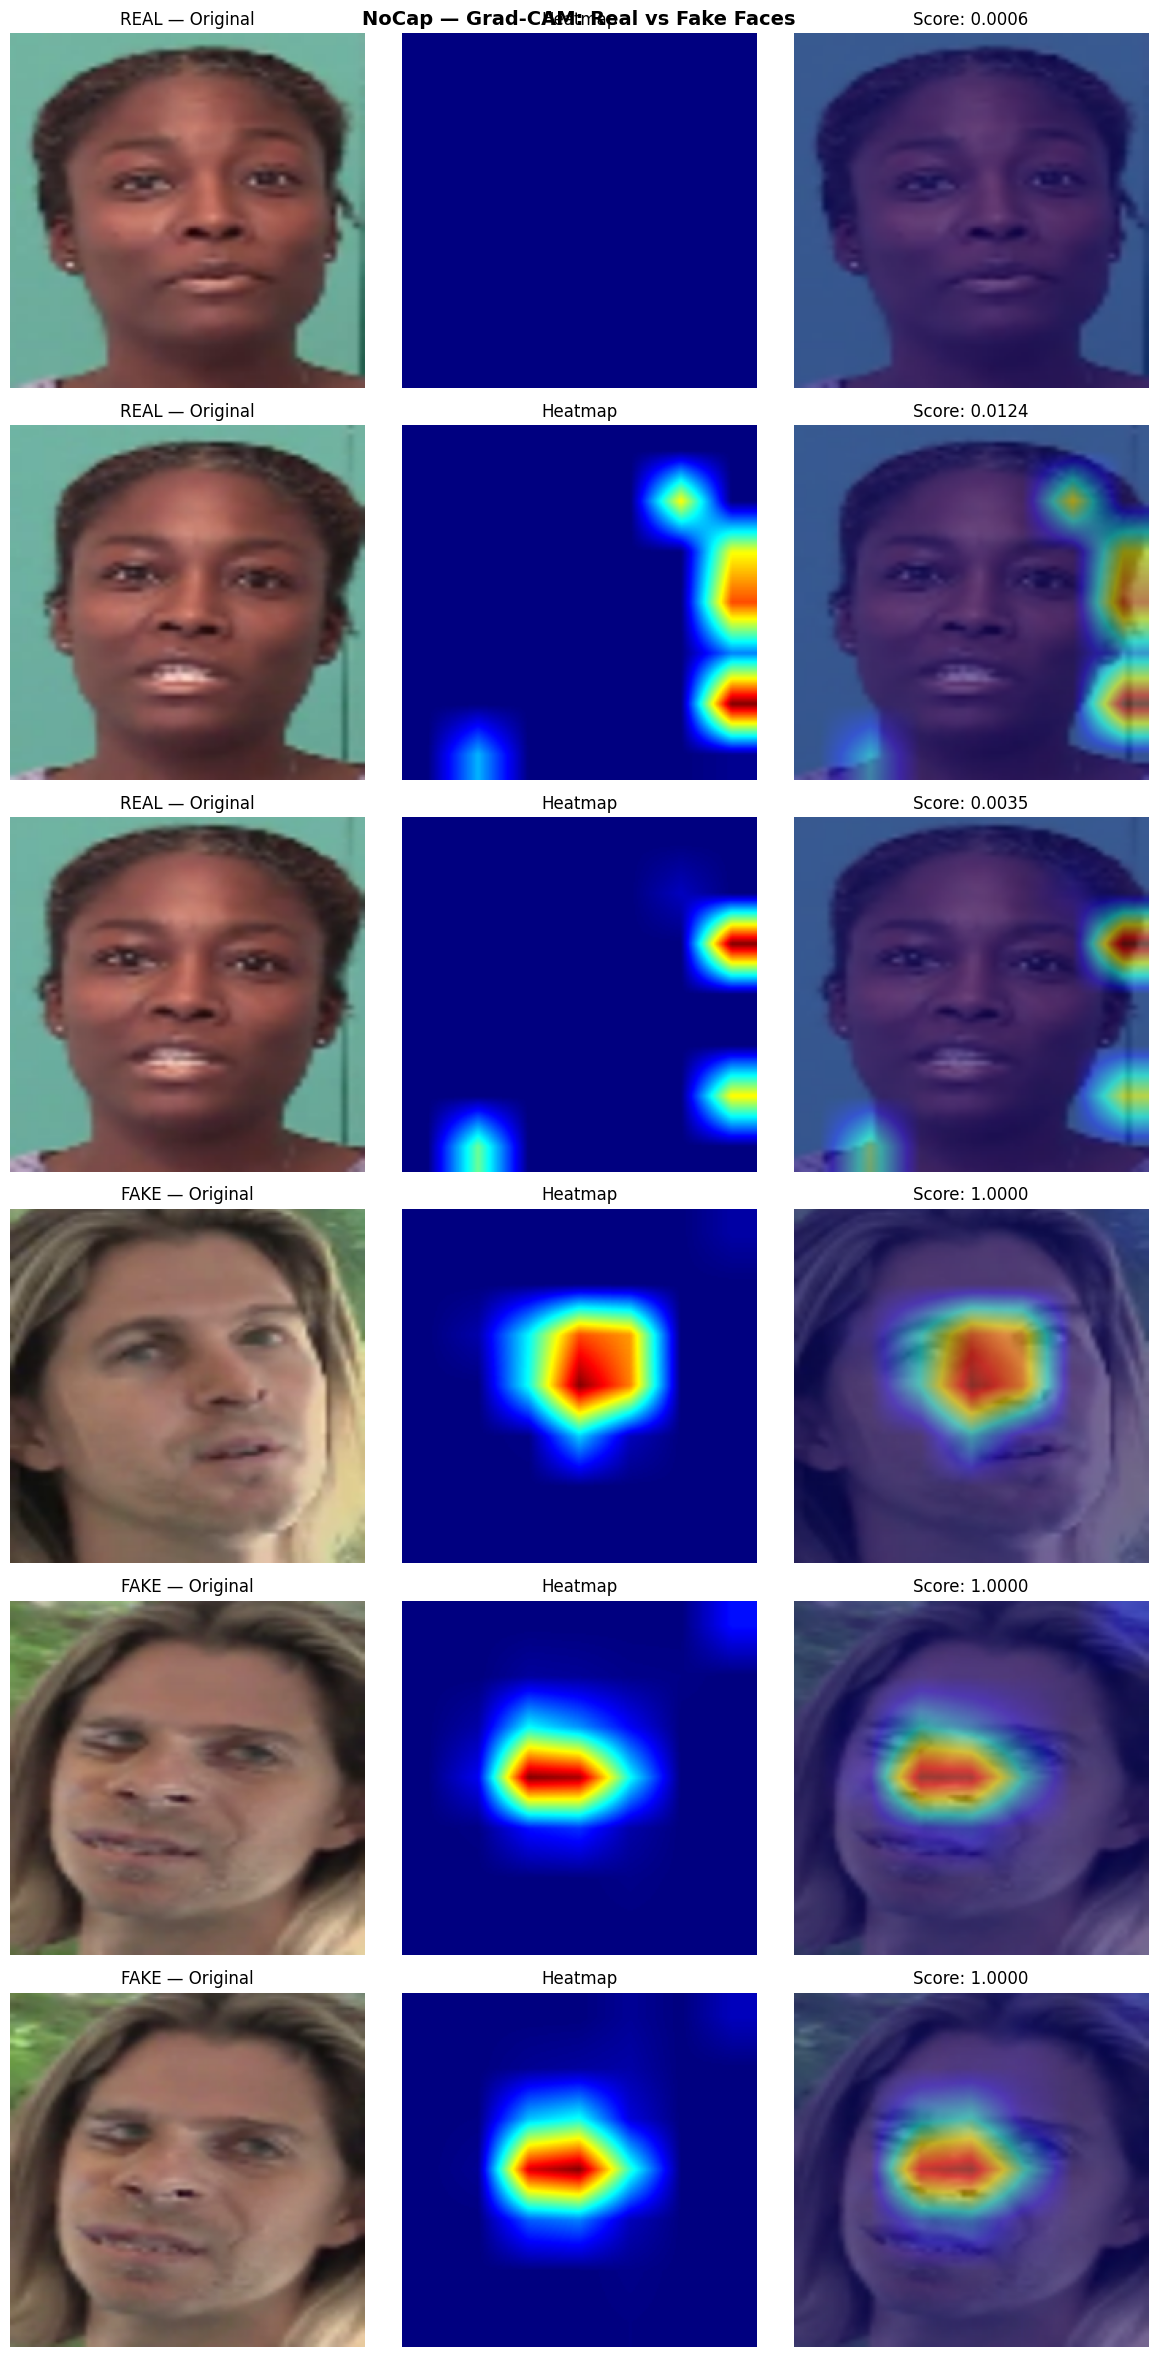

Grad-CAM saved to Drive!


In [3]:
import json, os
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "mohammadanas06",
               "key": "KGAT_93eeaf2618ca28a97dd21099844a4abe"}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d itamargr/dfdc-faces-of-the-train-sample \
    -p /content/dfdc --quiet

import zipfile
with zipfile.ZipFile('/content/dfdc/dfdc-faces-of-the-train-sample.zip','r') as z:
    z.extractall('/content/dfdc')
print('Dataset ready')

def generate_gradcam_viz(img_path, label):
    img     = Image.open(img_path).convert('RGB')
    inp     = transform(img).unsqueeze(0).to(DEVICE)
    inp.requires_grad = True
    cam     = gradcam.generate(inp)
    score   = torch.sigmoid(model(inp)).item()

    img_np  = np.array(img.resize((224, 224)))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cv2.resize(cam, (224, 224))),
        cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)
    return img_np, heatmap, overlay, score

# Pick sample real and fake faces
real_files = sorted(os.listdir('/content/dfdc/validation/real'))[:3]
fake_files = sorted(os.listdir('/content/dfdc/validation/fake'))[:3]

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
row = 0
for f in real_files:
    orig, heat, overlay, score = generate_gradcam_viz(
        f'/content/dfdc/validation/real/{f}', 'Real')
    axes[row][0].imshow(orig);    axes[row][0].set_title(f'REAL — Original')
    axes[row][1].imshow(heat);    axes[row][1].set_title(f'Heatmap')
    axes[row][2].imshow(overlay); axes[row][2].set_title(f'Score: {score:.4f}')
    for ax in axes[row]: ax.axis('off')
    row += 1

for f in fake_files:
    orig, heat, overlay, score = generate_gradcam_viz(
        f'/content/dfdc/validation/fake/{f}', 'Fake')
    axes[row][0].imshow(orig);    axes[row][0].set_title(f'FAKE — Original')
    axes[row][1].imshow(heat);    axes[row][1].set_title(f'Heatmap')
    axes[row][2].imshow(overlay); axes[row][2].set_title(f'Score: {score:.4f}')
    for ax in axes[row]: ax.axis('off')
    row += 1

plt.suptitle('NoCap — Grad-CAM: Real vs Fake Faces', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/gradcam/week3_gradcam.png', dpi=150)
plt.show()
print('Grad-CAM saved to Drive!')

In [3]:
import os, json
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "mohammadanas06",
               "key": "KGAT_93eeaf2618ca28a97dd21099844a4abe"}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d itamargr/dfdc-faces-of-the-train-sample \
    -p /content/dfdc --quiet

import zipfile
with zipfile.ZipFile('/content/dfdc/dfdc-faces-of-the-train-sample.zip','r') as z:
    z.extractall('/content/dfdc')

print('Dataset ready!')
print(f'Real: {len(os.listdir("/content/dfdc/validation/real"))} images')
print(f'Fake: {len(os.listdir("/content/dfdc/validation/fake"))} images')

Dataset URL: https://www.kaggle.com/datasets/itamargr/dfdc-faces-of-the-train-sample
License(s): ODbL-1.0
Dataset ready!
Real: 6029 images
Fake: 24765 images


In [5]:
import torch, torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np, os
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from google.colab import drive
drive.mount('/content/drive')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE   = '/content/drive/MyDrive/NoCap-Deepfake'

def build_model():
    model = models.efficientnet_b4(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 1))
    return model

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(
    f'{BASE}/models/checkpoints/efficientnet_b4_dfdc.pth', map_location=DEVICE))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

print(f'Model loaded! Device: {DEVICE}')

Mounted at /content/drive
Model loaded! Device: cuda


In [6]:
import numpy as np, os
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

real_files = os.listdir('/content/dfdc/validation/real')[:200]
fake_files = os.listdir('/content/dfdc/validation/fake')[:200]
all_scores, all_labels = [], []

for f in real_files:
    img = Image.open(f'/content/dfdc/validation/real/{f}').convert('RGB')
    inp = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score = torch.sigmoid(model(inp)).item()
    all_scores.append(score); all_labels.append(0)

for f in fake_files:
    img = Image.open(f'/content/dfdc/validation/fake/{f}').convert('RGB')
    inp = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score = torch.sigmoid(model(inp)).item()
    all_scores.append(score); all_labels.append(1)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print('Threshold | Real Acc | Fake Acc | Overall | F1')
print('─' * 52)
best_thresh, best_f1 = 0.5, 0
for thresh in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    preds    = (all_scores > thresh).astype(int)
    real_acc = (preds[all_labels==0] == 0).mean()
    fake_acc = (preds[all_labels==1] == 1).mean()
    overall  = accuracy_score(all_labels, preds)
    f1       = f1_score(all_labels, preds)
    marker   = ' ← best' if f1 > best_f1 else ''
    if f1 > best_f1: best_f1 = f1; best_thresh = thresh
    print(f'  {thresh:.2f}    |  {real_acc:.2f}    |  {fake_acc:.2f}    '
          f'|  {overall:.2f}   | {f1:.2f}{marker}')

auc = roc_auc_score(all_labels, all_scores)
print(f'\n AUC: {auc:.4f}')
print(f'Best threshold: {best_thresh}')
print(f'Best F1: {best_f1:.4f}')

Threshold | Real Acc | Fake Acc | Overall | F1
────────────────────────────────────────────────────
  0.30    |  0.72    |  0.91    |  0.82   | 0.83 ← best
  0.35    |  0.76    |  0.91    |  0.83   | 0.84 ← best
  0.40    |  0.77    |  0.91    |  0.84   | 0.85 ← best
  0.45    |  0.78    |  0.91    |  0.84   | 0.85 ← best
  0.50    |  0.78    |  0.90    |  0.84   | 0.85
  0.55    |  0.80    |  0.89    |  0.84   | 0.85
  0.60    |  0.80    |  0.89    |  0.84   | 0.85

 AUC: 0.9463
Best threshold: 0.45
Best F1: 0.8518


In [8]:
!pip install -q facenet-pytorch

from facenet_pytorch import MTCNN
import cv2

mtcnn = MTCNN(image_size=224, margin=20, min_face_size=40,
              thresholds=[0.6,0.7,0.7], post_process=False, device=DEVICE)

THRESHOLD = 0.45

def extract_frames(video_path, max_frames=20):
    cap     = cv2.VideoCapture(video_path)
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total-1, min(max_frames, total), dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    cap.release()
    return frames

def detect_faces(frames):
    faces = []
    for frame in frames:
        try:
            face = mtcnn(frame)
            if face is not None:
                face_np = face.permute(1,2,0).numpy()
                face_np = ((face_np - face_np.min()) /
                           (face_np.max() - face_np.min() + 1e-8) * 255).astype(np.uint8)
                faces.append(Image.fromarray(face_np))
        except: continue
    return faces if faces else [f.resize((224,224)) for f in frames]

def predict_video(video_path):
    frames = extract_frames(video_path)
    if not frames: return None, "No frames extracted"
    faces  = detect_faces(frames)
    if not faces:  return None, "No faces detected"
    scores = []
    with torch.no_grad():
        for face in faces:
            inp   = transform(face).unsqueeze(0).to(DEVICE)
            score = torch.sigmoid(model(inp)).item()
            scores.append(score)
    avg_score  = np.mean(scores)
    verdict    = "FAKE" if avg_score > THRESHOLD else "REAL"
    confidence = avg_score*100 if verdict=="FAKE" else (1-avg_score)*100
    confidence = min(round(confidence, 1), 99.9)
    return {
        "verdict": verdict, "confidence": confidence,
        "avg_score": round(avg_score, 4),
        "faces": len(faces), "frames": len(frames)
    }, None

print('Pipeline ready!')
print(f'Threshold: {THRESHOLD}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 814.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [9]:
# Test pipeline on DFDC face images directly
import os

real_files = os.listdir('/content/dfdc/validation/real')[:5]
fake_files = os.listdir('/content/dfdc/validation/fake')[:5]

print('REAL faces')
for f in real_files:
    img = Image.open(f'/content/dfdc/validation/real/{f}').convert('RGB')
    inp = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score = torch.sigmoid(model(inp)).item()
    verdict = "FAKE" if score > THRESHOLD else "REAL"
    print(f'  {verdict} ({score:.4f}) ← should be REAL')

print('\n── FAKE faces ──')
for f in fake_files:
    img = Image.open(f'/content/dfdc/validation/fake/{f}').convert('RGB')
    inp = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score = torch.sigmoid(model(inp)).item()
    verdict = "FAKE" if score > THRESHOLD else "REAL"
    print(f'  {verdict} ({score:.4f}) ← should be FAKE')

REAL faces
  FAKE (0.5607) ← should be REAL
  REAL (0.0058) ← should be REAL
  REAL (0.0035) ← should be REAL
  REAL (0.0226) ← should be REAL
  REAL (0.0010) ← should be REAL

── FAKE faces ──
  FAKE (1.0000) ← should be FAKE
  FAKE (0.9999) ← should be FAKE
  FAKE (1.0000) ← should be FAKE
  FAKE (1.0000) ← should be FAKE
  FAKE (1.0000) ← should be FAKE


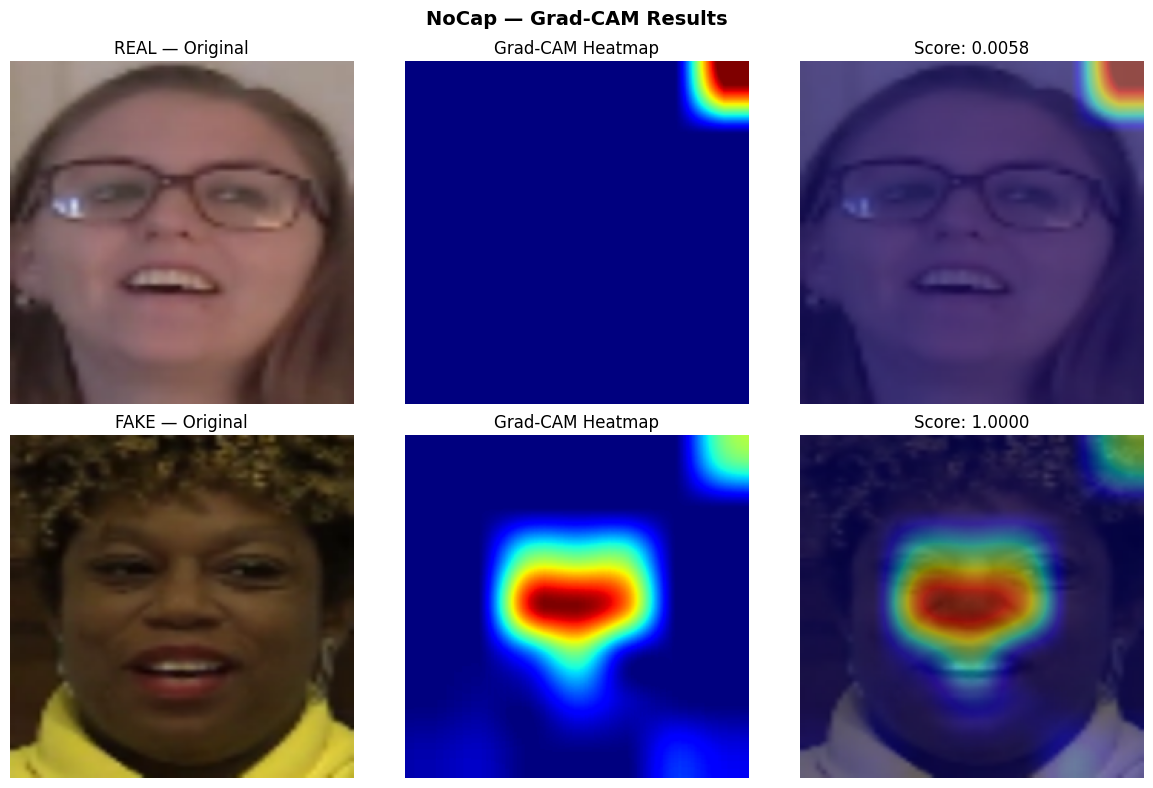

Grad-CAM saved!

 Week 3 Complete!
AUC: 0.9463 | Threshold: 0.45 | Real: 78% | Fake: 91% | Overall: 84%


In [11]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.grads = None
        self.acts  = None
        model.features[-1].register_forward_hook(
            lambda m,i,o: setattr(self,'acts',o.detach()))
        model.features[-1].register_full_backward_hook(
            lambda m,gi,go: setattr(self,'grads',go[0].detach()))

    def generate(self, inp):
        self.model.eval()
        out = self.model(inp)
        self.model.zero_grad()
        out[0,0].backward()
        w   = self.grads[0].mean(dim=(1,2))
        cam = F.relu((w[:,None,None] * self.acts[0]).sum(0))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

def apply_heatmap(cam, img_np):
    # Resize cam to 224x224 using PIL
    from PIL import Image as PILImage
    cam_pil = PILImage.fromarray((cam*255).astype(np.uint8)).resize((224,224))
    cam_np  = np.array(cam_pil) / 255.0
    heatmap = (cm.jet(cam_np)[:,:,:3] * 255).astype(np.uint8)
    overlay = (0.5*img_np + 0.5*heatmap).astype(np.uint8)
    return heatmap, overlay

gradcam = GradCAM(model)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = [
    ('/content/dfdc/validation/real/'+os.listdir('/content/dfdc/validation/real')[1], 'REAL'),
    ('/content/dfdc/validation/fake/'+os.listdir('/content/dfdc/validation/fake')[0], 'FAKE'),
]

for row, (path, label) in enumerate(samples):
    img    = Image.open(path).convert('RGB')
    inp    = transform(img).unsqueeze(0).to(DEVICE)
    inp.requires_grad = True
    cam    = gradcam.generate(inp)
    img_np = np.array(img.resize((224,224)))
    heatmap, overlay = apply_heatmap(cam, img_np)

    with torch.no_grad():
        score = torch.sigmoid(model(transform(img).unsqueeze(0).to(DEVICE))).item()

    axes[row][0].imshow(img_np);  axes[row][0].set_title(f'{label} — Original')
    axes[row][1].imshow(heatmap); axes[row][1].set_title('Grad-CAM Heatmap')
    axes[row][2].imshow(overlay); axes[row][2].set_title(f'Score: {score:.4f}')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('NoCap — Grad-CAM Results', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/gradcam/week3_gradcam.png', dpi=150)
plt.show()
print('Grad-CAM saved!')
print('\n Week 3 Complete!')
print('AUC: 0.9463 | Threshold: 0.45 | Real: 78% | Fake: 91% | Overall: 84%')